In [2]:
import pybamm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
import dfols
import signal
from scipy.integrate import solve_ivp
from scipy.fft import fft, fftfreq, fftshift
from scipy.signal import savgol_filter
from scipy.signal import find_peaks
from scipy import interpolate, integrate
from scipy.optimize import curve_fit
from stopit import threading_timeoutable as timeoutable
import os, sys
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))))
from batfuns import *
plt.rcParams = set_rc_params(plt.rcParams)
import winsound

eSOH_DIR = "../data/esoh_R/"
oCV_DIR = "../data/ocv/"
hppc_DIR = "../data/hppc/"
cyc_DIR = "../data/cycling/"
crate_DIR = "../data/crate/"
fig_DIR = "../figures/figures_paper/"
res_DIR = "../data/results_paper/"
# %matplotlib widget

In [ ]:
cell = 9
cell_no = f"{cell:02d}"
df1 = pd.read_csv(oCV_DIR + f"ocv_data_cell_{cell_no}.csv")
df1["t"] = df1["t"]/3600
df2 = pd.read_csv(hppc_DIR + f"hppc_data_cell_{cell_no}.csv")
df2["t"] = df2["Time [s]"]/3600
df2["N"] = df2["Cycle number"]  
df3 = pd.read_csv(crate_DIR + f"crate_data_cell_{cell_no}.csv")
df3["N"] = df3["Cycle number"]  
df3["t"] = df3["Time [s]"]/3600
df4 = pd.read_csv(cyc_DIR + f"cycling_data_cell_{cell_no}.csv")
df4["N"] = df4["Cycle number"]  
df4["t"] = df4["Time [s]"]/3600

In [55]:
df4.columns

Index(['Time [s]', 'Current [mA]', 'Voltage [V]', 'Expansion [mu m]',
       'Temperature [C]', 'Q [Ah]', 'Capacity [Ah]', 'Cycle number'],
      dtype='object')

In [46]:
df1["N"].unique()
# df2["N"].unique()
# df3["N"].unique()

array([  0,  21,  52,  83, 114, 145], dtype=int64)

In [73]:
n = 52
df1_1 = df1.query(f"N == {n}")
df2_1 = df2.query(f"N == {n}")
df3_1 = df3.query(f"N == {n}")
df4_1 = df4[df4["N"].isin(np.arange(n-4,n+4))]
df4_1["t"] = df4_1["t"] - df4_1["t"].iloc[0]

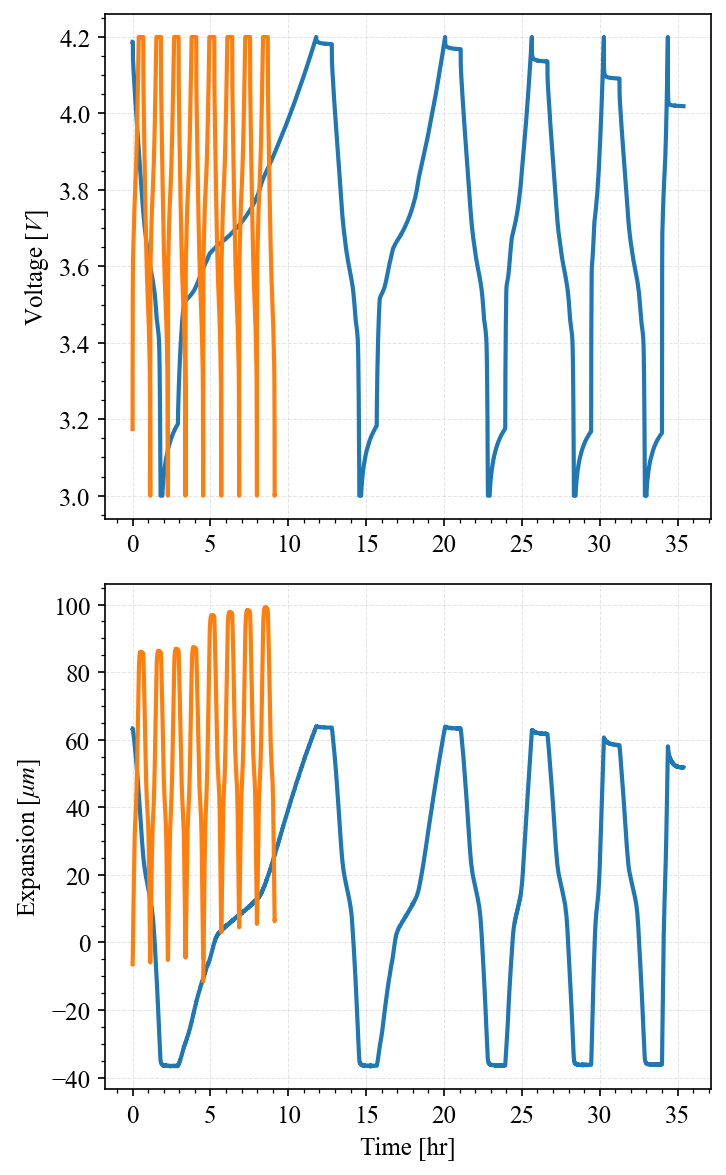

In [76]:
fig,ax = plt.subplots(2,1,figsize=(5,8))
ax1 = ax.flat[0]
ax1.plot(df3_1["t"],df3_1["Voltage [V]"])
ax1.plot(df4_1["t"],df4_1["Voltage [V]"])
ax1.set_ylabel(r"Voltage [$V$]")
ax2 = ax.flat[1]
ax2.plot(df3_1["t"],df3_1["Expansion [mu m]"])
ax2.plot(df4_1["t"],df4_1["Expansion [mu m]"])
ax2.set_ylabel(r"Expansion [$\mu m$]")
ax2.set_xlabel("Time [hr]")
fig.tight_layout()
fig.savefig(fig_DIR + "timeseries_exp_{cell_no}_{n}.png",dpi=300)

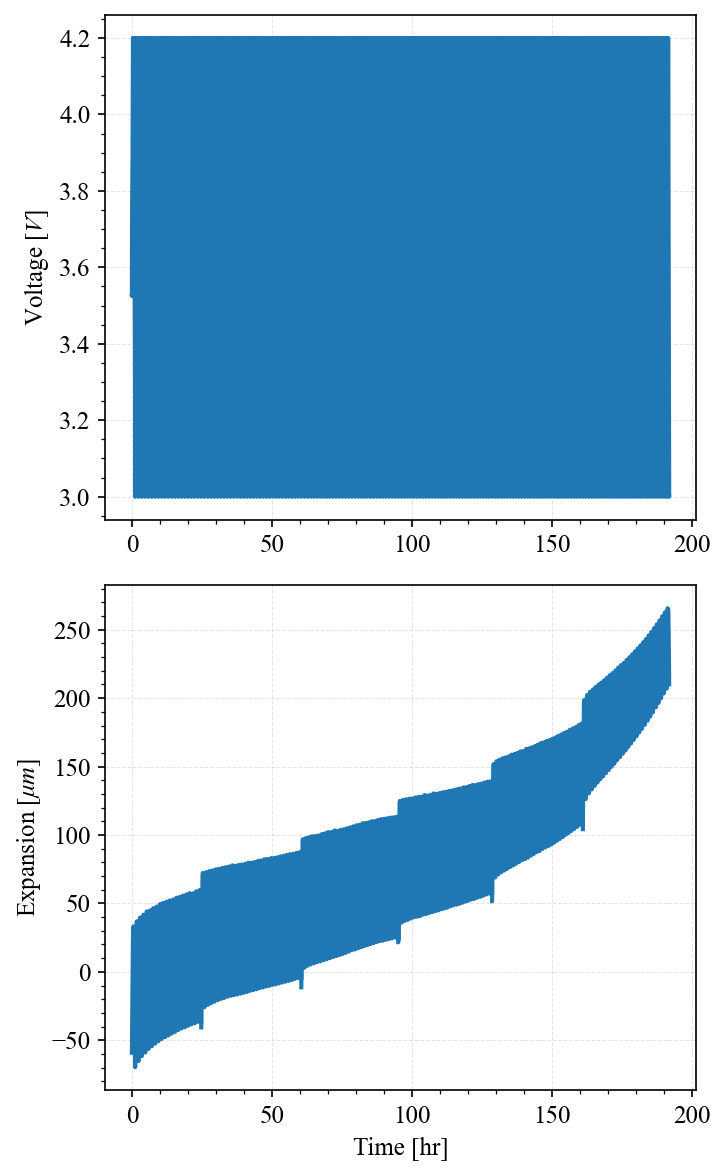

In [77]:
fig,ax = plt.subplots(2,1,figsize=(5,8))
ax1 = ax.flat[0]
ax1.plot(df4["t"],df4["Voltage [V]"])
ax1.set_ylabel(r"Voltage [$V$]")
ax2 = ax.flat[1]
ax2.plot(df4["t"],df4["Expansion [mu m]"])
ax2.set_ylabel(r"Expansion [$\mu m$]")
ax2.set_xlabel("Time [hr]")
fig.tight_layout()
fig.savefig(fig_DIR + "timeseries_exp_{cell_no}_full.png",dpi=300)